# Simple Linear Regression with Diagnostics

Objective: Build a linear regression model and visualize its performance.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv('titanic.csv')

In [46]:
# Predict Fare from Age
df_clean = df[['Age', 'Fare']].dropna()
X = df_clean[['Age']].values
y = df_clean['Fare'].values

print(f"Dataset: {len(X)} samples")
print(f"Predicting: Fare from Age")

Dataset: 714 samples
Predicting: Fare from Age


In [47]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")


Training set: 571 samples
Test set: 143 samples


In [48]:
# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nModel equation:")
print(f"Fare = {model.coef_[0]:.4f} * Age + {model.intercept_:.4f}")


Model equation:
Fare = 0.3561 * Age + 24.3896


In [50]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
print(f"\nPerformance Metrics:")
print(f"Training R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")


Performance Metrics:
Training R²: 0.0112
Test R²: 0.0038
Training RMSE: 49.25
Test RMSE: 64.40


In [52]:
# Residuals
test_residuals = y_test - y_test_pred
print(f"\nResidual statistics:")
print(f"Mean: {np.mean(test_residuals):.4f} (should be near 0)")
print(f"Std: {np.std(test_residuals):.2f}")


Residual statistics:
Mean: -1.3525 (should be near 0)
Std: 64.39


### VISUALIZATIONS (4 plots)

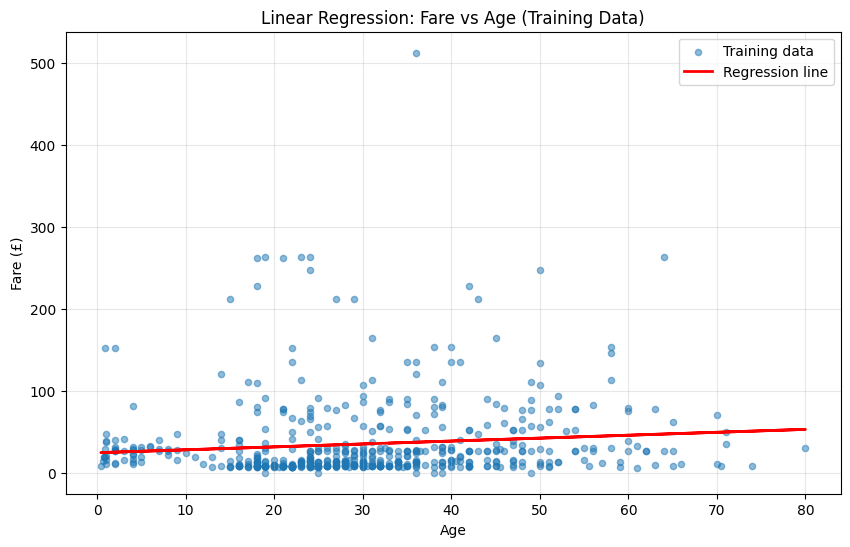

In [53]:
# Plot 1: Training data with regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.5, s=20, label='Training data')
plt.plot(X_train, y_train_pred, 'r-', linewidth=2, label='Regression line')
plt.xlabel('Age')
plt.ylabel('Fare (£)')
plt.title('Linear Regression: Fare vs Age (Training Data)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

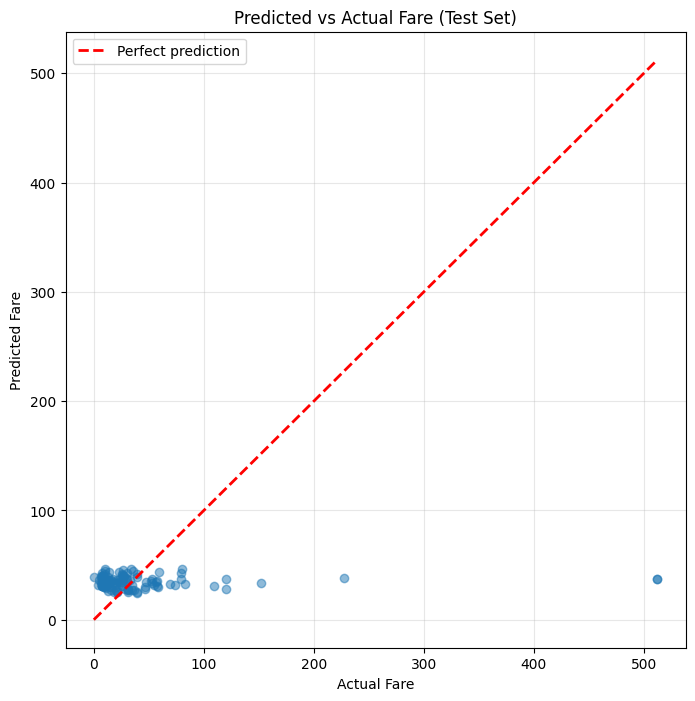

In [54]:
# Plot 2: Predicted vs Actual (test set)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Predicted vs Actual Fare (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

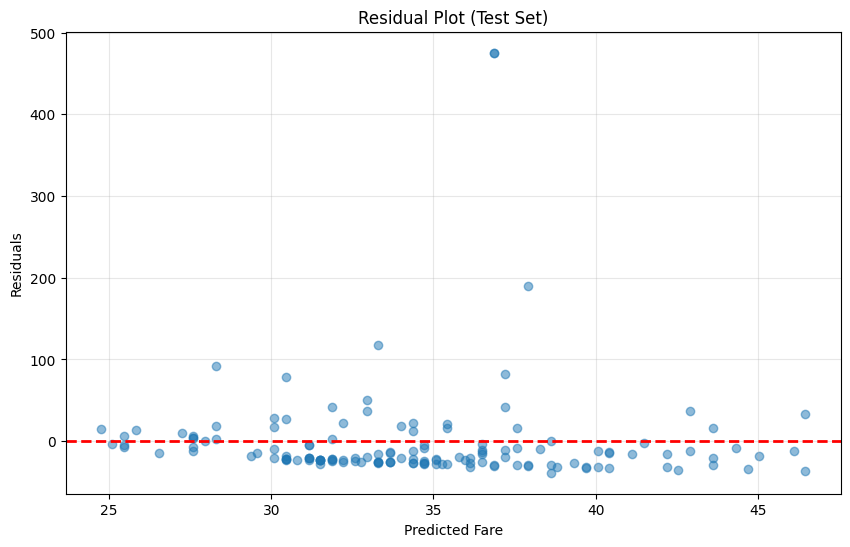

In [55]:
# Plot 3: Residuals plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, test_residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.title('Residual Plot (Test Set)')
plt.grid(alpha=0.3)
plt.show()

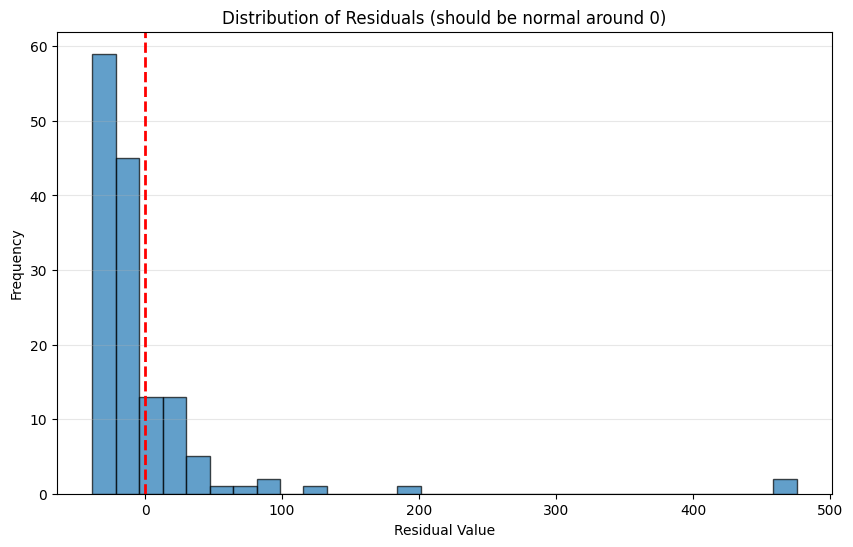

In [56]:
# Plot 4: Residuals histogram
plt.figure(figsize=(10, 6))
plt.hist(test_residuals, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (should be normal around 0)')
plt.grid(axis='y', alpha=0.3)
plt.show()

-----------------------

# PyTorch: Tensor Operations and Linear Regression from Scratch

Objective: Learn PyTorch tensors and implement linear regression manually.

In [57]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

In [58]:
# Simple example: Predict Fare from Age
df_clean = df[['Age', 'Fare']].dropna()
ages = df_clean['Age'].values
fares = df_clean['Fare'].values

In [59]:
print("="*60)
print("PYTORCH TENSOR BASICS")
print("="*60)

# Convert to PyTorch tensors
X = torch.tensor(ages, dtype=torch.float32).reshape(-1, 1)
y = torch.tensor(fares, dtype=torch.float32).reshape(-1, 1)

print(f"\nData shape: X={X.shape}, y={y.shape}")
print(f"First 5 ages: {X[:5].flatten()}")
print(f"First 5 fares: {y[:5].flatten()}")

PYTORCH TENSOR BASICS

Data shape: X=torch.Size([714, 1]), y=torch.Size([714, 1])
First 5 ages: tensor([22., 38., 26., 35., 35.])
First 5 fares: tensor([ 7.2500, 71.2833,  7.9250, 53.1000,  8.0500])


In [61]:
# Normalize features (important!)
X_mean = torch.mean(X)
X_std = torch.std(X)
X_normalized = (X - X_mean) / X_std

y_mean = torch.mean(y)
y_std = torch.std(y)
y_normalized = (y - y_mean) / y_std

print(f"\nNormalization:")
print(f"Age: mean={X_mean:.2f}, std={X_std:.2f}")
print(f"Fare: mean={y_mean:.2f}, std={y_std:.2f}")


Normalization:
Age: mean=29.70, std=14.53
Fare: mean=34.69, std=52.92


In [62]:
# Initialize parameters (weight and bias)
torch.manual_seed(42)
w = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"\nInitial parameters:")
print(f"Weight: {w.item():.4f}")
print(f"Bias: {b.item():.4f}")


Initial parameters:
Weight: 0.3367
Bias: 0.1288


In [64]:
# Training loop
learning_rate = 0.01
n_epochs = 100
losses = []

print("\nTraining...")
for epoch in range(n_epochs):
    # Forward pass: y_pred = X * w + b
    y_pred = torch.mm(X_normalized, w) + b
    
    # Compute loss (Mean Squared Error)
    loss = torch.mean((y_pred - y_normalized)**2)
    losses.append(loss.item())
    
    # Backward pass
    loss.backward()
    
    # Update parameters (gradient descent)
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
        
        # Zero gradients
        w.grad.zero_()
        b.grad.zero_()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}")

print(f"\nFinal parameters:")
print(f"Weight: {w.item():.4f}")
print(f"Bias: {b.item():.4f}")


Training...
Epoch [20/100], Loss: 0.9900
Epoch [40/100], Loss: 0.9897
Epoch [60/100], Loss: 0.9895
Epoch [80/100], Loss: 0.9894
Epoch [100/100], Loss: 0.9894

Final parameters:
Weight: 0.1003
Bias: 0.0023


In [65]:
# Make predictions
with torch.no_grad():
    y_pred_normalized = torch.mm(X_normalized, w) + b
    # Denormalize
    y_pred = y_pred_normalized * y_std + y_mean

# Calculate R²
y_mean_value = torch.mean(y)
ss_tot = torch.sum((y - y_mean_value)**2)
ss_res = torch.sum((y - y_pred)**2)
r2 = 1 - ss_res / ss_tot

print(f"\nR² Score: {r2.item():.4f}")


R² Score: 0.0092


### VISUALIZATIONS (4 plots)

In [66]:
# Convert to numpy for plotting
X_np = X.numpy().flatten()
y_np = y.numpy().flatten()
y_pred_np = y_pred.numpy().flatten()

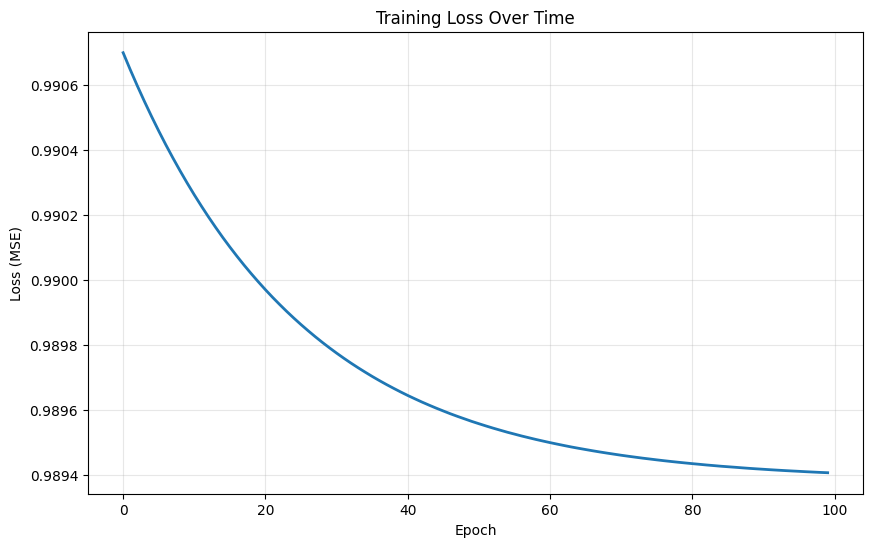

In [67]:
# Plot 1: Training loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(alpha=0.3)
plt.show()

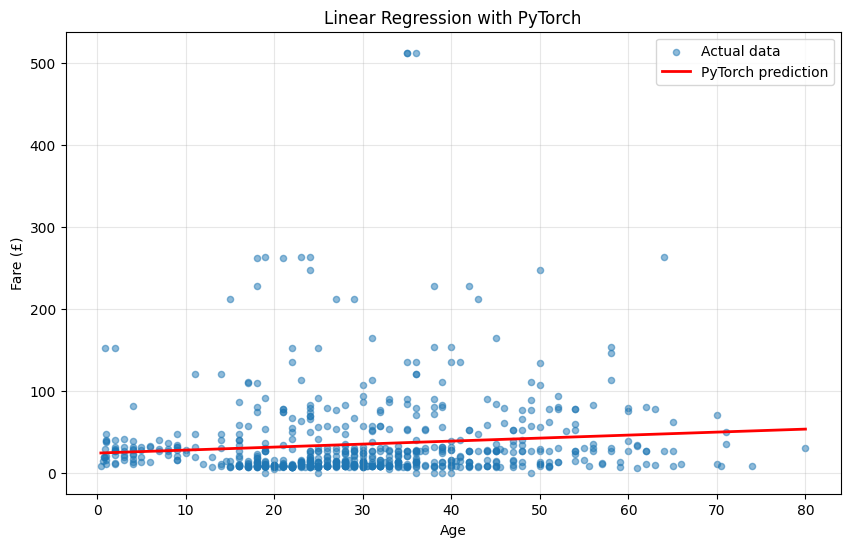

In [68]:
# Plot 2: Data with regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_np, y_np, alpha=0.5, s=20, label='Actual data')
# Sort for line plot
sorted_idx = np.argsort(X_np)
plt.plot(X_np[sorted_idx], y_pred_np[sorted_idx], 'r-', 
         linewidth=2, label='PyTorch prediction')
plt.xlabel('Age')
plt.ylabel('Fare (£)')
plt.title('Linear Regression with PyTorch')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

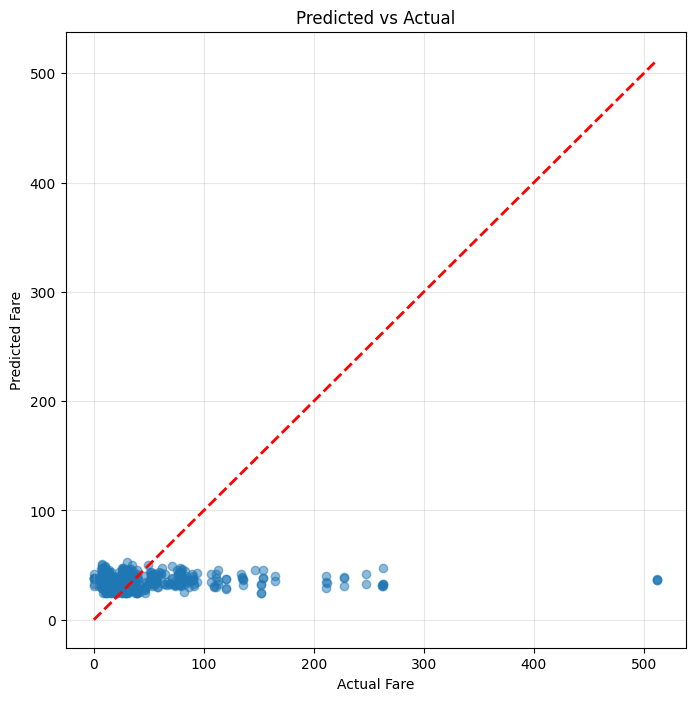

In [69]:
# Plot 3: Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(y_np, y_pred_np, alpha=0.5)
plt.plot([y_np.min(), y_np.max()], [y_np.min(), y_np.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Predicted vs Actual')
plt.grid(alpha=0.3)
plt.show()

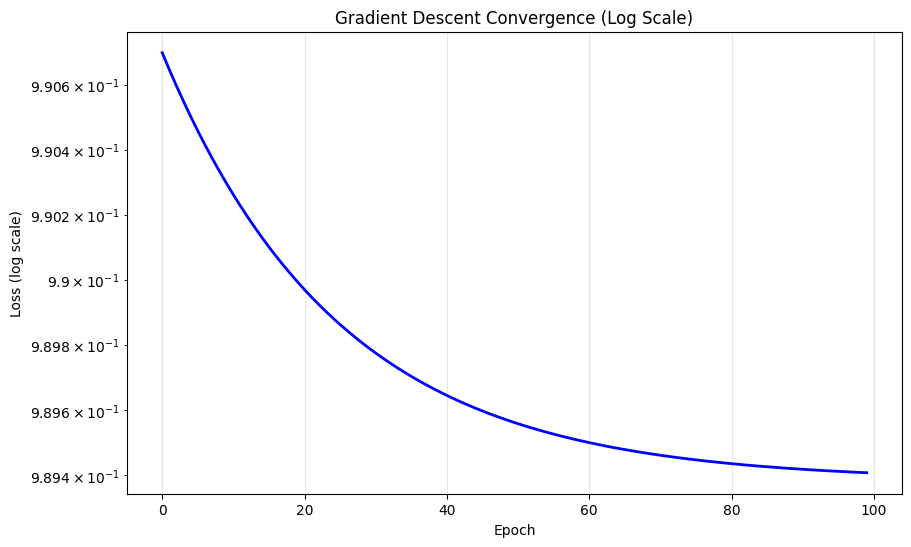

In [70]:
# Plot 4: Gradient descent path (2D visualization of loss surface)
plt.figure(figsize=(10, 6))
plt.semilogy(losses, linewidth=2, color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Gradient Descent Convergence (Log Scale)')
plt.grid(alpha=0.3)
plt.show()